# Predictive Maintenance for NASA Turbofan Engines (C-MAPSS)
### End-to-End Notebook — RUL Prediction, Forecasting & GenAI Maintenance Assistant

**What is included in this Notebook**
1. Understanding the Data
2. Exploratory Data Analysis & Visualization
3. Data Cleaning & Feature Engineering
4. RUL Baseline Model
5. Advanced ML Models (model comparison + best model selection & persistence)
6. Future Sensor Forecasting (t+2, t+5 cycles ahead)
7. GenAI Maintenance Assistant (LangChain + Google Gemini)
8. Professional Streamlit Dashboard (companion app, run separately)

In [ ]:
## 0. Setup & Configuration

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

In [12]:
# ---- Configuration ----
DATASET_ID   = "FD001"                 # one of FD001, FD002, FD003, FD004
DATA_DIR = PROJECT_ROOT / "data" / "archive" / "CMaps"            
MODEL_DIR    = PROJECT_ROOT / "models"
RUL_CLIP     = 125                     # piecewise-linear RUL cap (standard C-MAPSS practice)
HORIZONS     = [2, 5]                  # forecasting horizons in cycles

In [13]:
DATA_DIR

WindowsPath('e:/ISCOP institute/Seminar/Seminar (12-7-2026)/NASA turbofan predictive maintenance/data/archive/CMaps')

## 1. Understanding the Data

The C-MAPSS dataset simulates turbofan engine degradation. Each engine (`unit_number`) runs until failure across multiple operational cycles (`time_in_cycles`). Each row records:

- **unit_number**
- **time_in_cycles**
- **3 operational settings** (`op_setting_1..3`) — flight conditions (altitude, Mach number, throttle).
- **21 sensor measurements** (`sensor_1..21`) — temperatures, pressures, speeds, fuel flow ratios, etc.

In [14]:
# Column schema (fixed for all C-MAPSS subsets)
INDEX_COLS   = ["unit_number", "time_in_cycles"]
SETTING_COLS = ["op_setting_1", "op_setting_2", "op_setting_3"]
SENSOR_COLS = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',        # Temperatures & Pressures
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',       # Rotational Speeds
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32' # Others
]
#SENSOR_COLS  = [f"sensor_{i}" for i in range(1, 22)]
COLS         = INDEX_COLS + SETTING_COLS + SENSOR_COLS

SENSOR_DESCRIPTIONS = {
    "sensor_1": "Total temperature at fan inlet (T2)",
    "sensor_2": "Total temperature at LPC outlet (T24)",
    "sensor_3": "Total temperature at HPC outlet (T30)",
    "sensor_4": "Total temperature at LPT outlet (T50)",
    "sensor_5": "Pressure at fan inlet (P2)",
    "sensor_6": "Total pressure in bypass-duct (P15)",
    "sensor_7": "Total pressure at HPC outlet (P30)",
    "sensor_8": "Physical fan speed (Nf)",
    "sensor_9": "Physical core speed (Nc)",
    "sensor_10": "Engine pressure ratio (epr)",
    "sensor_11": "Static pressure at HPC outlet (Ps30)",
    "sensor_12": "Ratio of fuel flow to Ps30 (phi)",
    "sensor_13": "Corrected fan speed (NRf)",
    "sensor_14": "Corrected core speed (NRc)",
    "sensor_15": "Bypass Ratio (BPR)",
    "sensor_16": "Burner fuel-air ratio (farB)",
    "sensor_17": "Bleed Enthalpy (htBleed)",
    "sensor_18": "Demanded fan speed (Nf_dmd)",
    "sensor_19": "Demanded corrected fan speed (PCNfR_dmd)",
    "sensor_20": "HPT coolant bleed (W31)",
    "sensor_21": "LPT coolant bleed (W32)",
}

In [15]:
import os

In [16]:
def load_data(dataset_id, data_dir):
    train_path = os.path.join(data_dir, f"train_{dataset_id}.txt")
    test_path = os.path.join(data_dir, f"test_{dataset_id}.txt")
    rul_path = os.path.join(data_dir, f"rul_{dataset_id}.txt")
  
    # read dataset files
    train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=COLS)
    test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None, names=COLS)
    rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None, names=["RUL"])
    return train_df, test_df, rul_df

train_df, test_df, rul_df = load_data(DATASET_ID, DATA_DIR)
print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape} | RUL rows: {rul_df.shape[0]}")

Train shape: (20631, 26) | Test shape: (13096, 26) | RUL rows: 100


In [17]:
train_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [18]:
print("Engines in training set:", train_df["unit_number"].nunique())
print("Engines in test set:", test_df["unit_number"].nunique())

print("\nCycle length statistics per engine (train):")
display(train_df.groupby("unit_number")["time_in_cycles"].max().describe())

print("\nMissing values (train):", train_df.isna().sum().sum())
print("Missing values (test):", test_df.isna().sum().sum())

Engines in training set: 100
Engines in test set: 100

Cycle length statistics per engine (train):


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64


Missing values (train): 0
Missing values (test): 0


In [19]:
train_df[SETTING_COLS + SENSOR_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200
P15,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
P30,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600


## 2. Exploratory Data Analysis & Visualization

Goals:
- Understand engine run-to-failure lengths.
- Identify constant / near-constant sensors (no diagnostic value).
- Visualize how sensors trend as engines approach failure.
- Inspect correlations between sensors.

In [20]:
# Distribution of engine lifetimes
max_cycles = train_df.groupby("unit_number")["time_in_cycles"].max()



In [21]:
max_cycles

unit_number
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time_in_cycles, Length: 100, dtype: int64

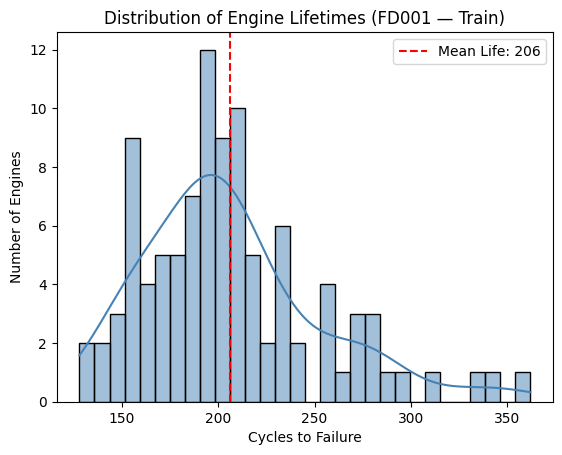

In [22]:
plt.figure()
sns.histplot(max_cycles, bins=30, kde=True, color="steelblue")
plt.title(f"Distribution of Engine Lifetimes ({DATASET_ID} — Train)")
plt.axvline(max_cycles.mean(), color='r', linestyle='--', label=f'Mean Life: {int(max_cycles.mean())}')
plt.xlabel("Cycles to Failure")
plt.ylabel("Number of Engines")
plt.legend()
plt.show()

Near-constant sensors detected: ['T2', 'PCNfR_dmd', 'Nf_dmd', 'epr', 'farB', 'P2']


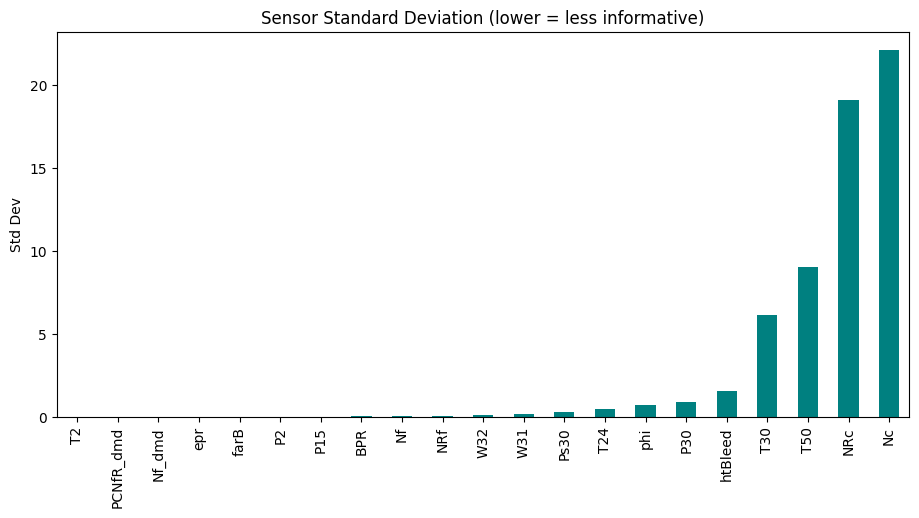

In [23]:
# Identify low-variance / constant sensors (little to no diagnostic signal)
sensor_std = train_df[SENSOR_COLS].std().sort_values()
low_variance_sensors = sensor_std[sensor_std < 1e-3].index.tolist()

print("Near-constant sensors detected:", low_variance_sensors)

plt.figure(figsize=(11, 5))
sensor_std.plot(kind="bar", color="teal")
plt.title("Sensor Standard Deviation (lower = less informative)")
plt.ylabel("Std Dev")
plt.show()

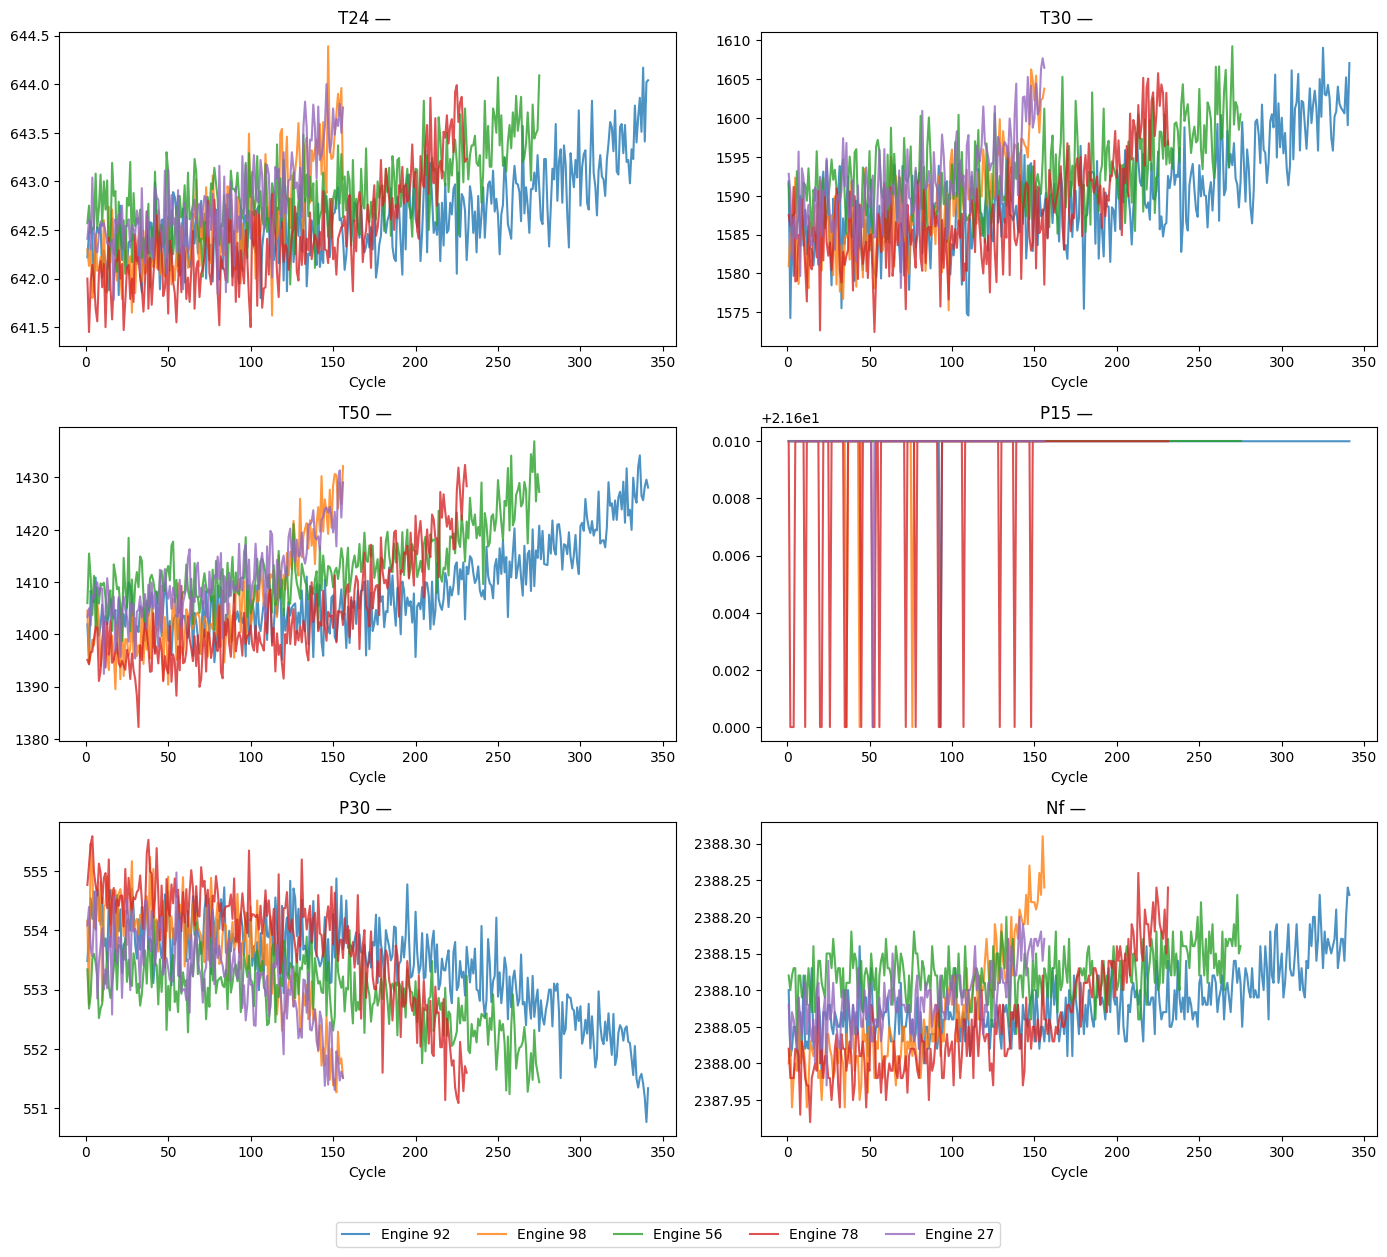

In [24]:
# Sensor trends across life percentage for a handful of sample engines
sample_units = train_df["unit_number"].drop_duplicates().sample(5)
informative_sensors = [s for s in SENSOR_COLS if s not in low_variance_sensors][:6]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, sensor in zip(axes.flatten(), informative_sensors):
    for unit in sample_units:
        eng = train_df[train_df["unit_number"] == unit]
        ax.plot(eng["time_in_cycles"], eng[sensor], alpha=0.8, label=f"Engine {unit}")
    ax.set_title(sensor + " — " + SENSOR_DESCRIPTIONS.get(sensor, ""))
    ax.set_xlabel("Cycle")
plt.tight_layout()
plt.legend(loc="upper center", bbox_to_anchor=(-0.15, -0.25), ncol=5)
plt.show()

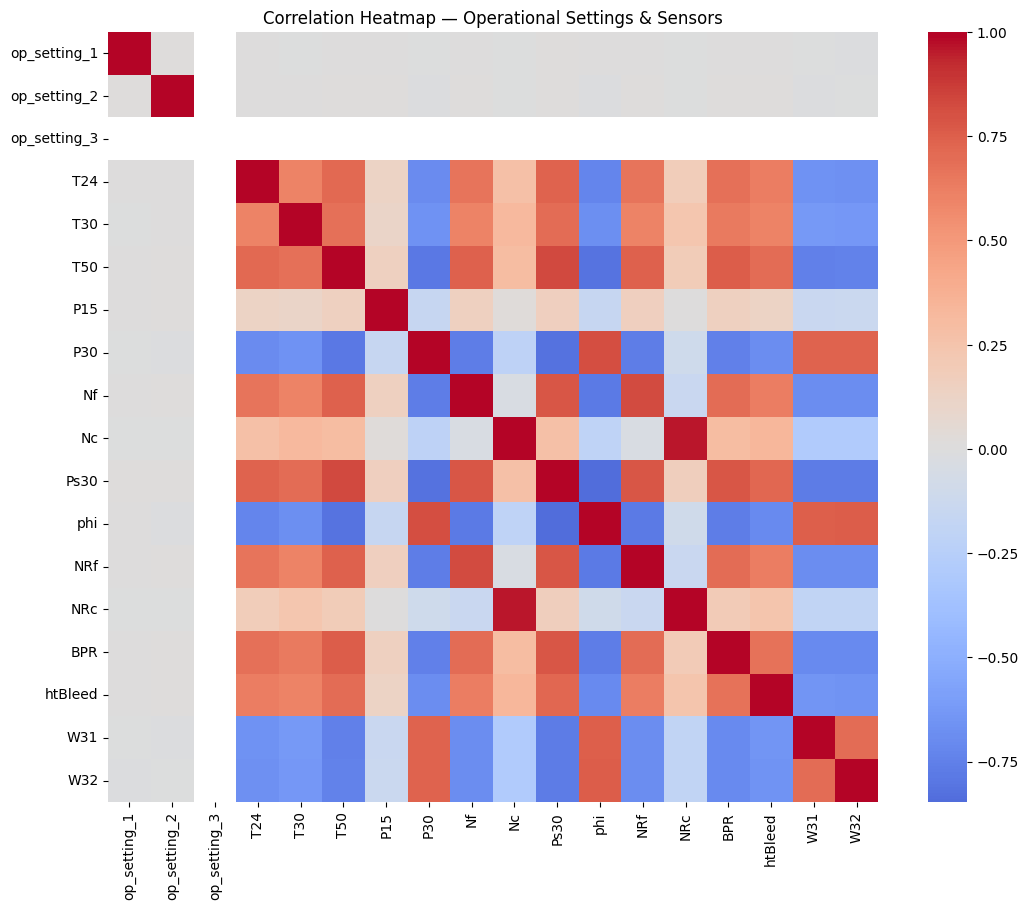

In [25]:
# Correlation heatmap of informative sensors + operational settings
corr_cols = SETTING_COLS + [s for s in SENSOR_COLS if s not in low_variance_sensors]
corr = train_df[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Heatmap — Operational Settings & Sensors")
plt.show()

## 3. Data Cleaning & Feature Engineering

Steps:
1. **Compute RUL labels** for training data: `RUL = max_cycle(unit) - current_cycle`, then apply the standard **piecewise-linear clip** at `RUL_CLIP` (engines behave nominally early in life; degradation is only meaningful near failure — clipping avoids penalizing the model for early-life noise).
2. **Drop near-constant sensors** identified in EDA (no signal).
3. **Normalize** operational settings + sensors (per-subset scaling; C-MAPSS FD002/FD004 have multiple operating regimes, so in production you'd cluster by regime first — noted here for completeness).
4. **Engineer rolling features**: rolling mean & std (window=5) per sensor to capture degradation trend and volatility, which are strong RUL predictors beyond raw readings.

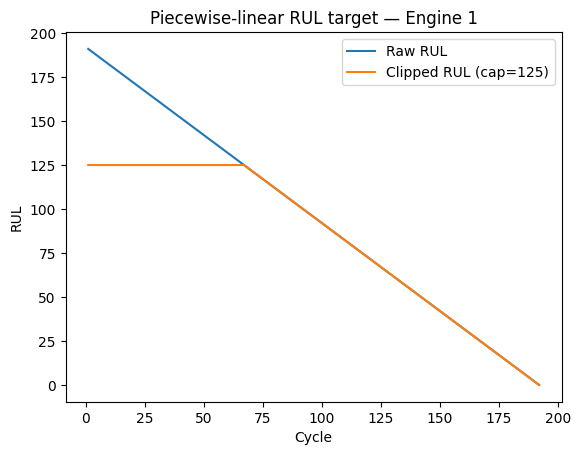

In [26]:
def add_rul(df):
    max_cycle = df.groupby("unit_number")["time_in_cycles"].transform("max")
    df = df.copy()
    df["RUL"] = max_cycle - df["time_in_cycles"]
    return df

train_df = add_rul(train_df)
train_df["RUL_clipped"] = train_df["RUL"].clip(upper=RUL_CLIP)

plt.figure()
sample_eng = train_df[train_df.unit_number == 1]
plt.plot(sample_eng.time_in_cycles, sample_eng.RUL, label="Raw RUL")
plt.plot(sample_eng.time_in_cycles, sample_eng.RUL_clipped, label=f"Clipped RUL (cap={RUL_CLIP})")
plt.xlabel("Cycle"); plt.ylabel("RUL"); plt.title("Piecewise-linear RUL target — Engine 1")
plt.legend(); plt.show()

In [27]:
train_df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,T2,T24,T30,T50,P2,...,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL,RUL_clipped
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1,1


In [28]:
low_variance_sensors

['T2', 'PCNfR_dmd', 'Nf_dmd', 'epr', 'farB', 'P2']

# Preprocessing

### Remove low variance sensors (constant reading sensors) from the final training dataset

In [29]:
FEATURE_SENSORS = [s for s in SENSOR_COLS if s not in low_variance_sensors]
FEATURE_COLS_BASE = SETTING_COLS + FEATURE_SENSORS

In [30]:
FEATURE_SENSORS

['T24',
 'T30',
 'T50',
 'P15',
 'P30',
 'Nf',
 'Nc',
 'Ps30',
 'phi',
 'NRf',
 'NRc',
 'BPR',
 'htBleed',
 'W31',
 'W32']

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_df[FEATURE_COLS_BASE] = scaler.fit_transform(train_df[FEATURE_COLS_BASE])
test_df[FEATURE_COLS_BASE]  = scaler.transform(test_df[FEATURE_COLS_BASE])

print("Scaled feature columns:", len(FEATURE_COLS_BASE))

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Scaled feature columns: 18


In [32]:
def add_rolling_features(df, sensors, window=5):
    df = df.sort_values(["unit_number", "time_in_cycles"]).copy()
    grouped = df.groupby("unit_number")[sensors]
    roll_mean = grouped.rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True)
    roll_std  = grouped.rolling(window=window, min_periods=1).std().fillna(0).reset_index(level=0, drop=True)
    roll_mean.columns = [f"{c}_rmean{window}" for c in sensors]
    roll_std.columns  = [f"{c}_rstd{window}" for c in sensors]
    return pd.concat([df, roll_mean, roll_std], axis=1)

train_fe = add_rolling_features(train_df, FEATURE_SENSORS, window=5)
test_fe  = add_rolling_features(test_df, FEATURE_SENSORS, window=5)

ROLL_COLS = [c for c in train_fe.columns if "_rmean5" in c or "_rstd5" in c]
FEATURE_COLS = FEATURE_COLS_BASE + ROLL_COLS
print("Total engineered features:", len(FEATURE_COLS))
train_fe[["unit_number", "time_in_cycles"] + ROLL_COLS[:4]].head()

Total engineered features: 48


,unit_number,time_in_cycles,T24_rmean5,T30_rmean5,T50_rmean5,P15_rmean5
0,1,1,0.183735,0.406802,0.309757,1.0
1,1,2,0.233434,0.429911,0.331195,1.0
2,1,3,0.270080,0.409781,0.344306,1.0
3,1,4,0.288404,0.371376,0.341028,1.0
4,1,5,0.300602,0.348594,0.353747,1.0


In [33]:
train_fe.shape

(20631, 58)

In [34]:
# For the test set, evaluation uses only the LAST cycle of each engine trajectory (standard C-MAPSS protocol)
test_last = test_fe.groupby("unit_number").tail(1).reset_index(drop=True)
test_last["RUL"] = rul_df["RUL"].values
test_last["RUL_clipped"] = test_last["RUL"].clip(upper=RUL_CLIP)

X_train = train_fe[FEATURE_COLS]
y_train = train_fe["RUL_clipped"]
X_test  = test_last[FEATURE_COLS]
y_test  = test_last["RUL_clipped"]

print(X_train.shape, X_test.shape)

(20631, 48) (100, 48)


In [35]:
test_last

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,T2,T24,T30,T50,P2,...,Ps30_rstd5,phi_rstd5,NRf_rstd5,NRc_rstd5,BPR_rstd5,htBleed_rstd5,W31_rstd5,W32_rstd5,RUL,RUL_clipped
0,1,31,0.465517,0.833333,0.0,518.67,0.412651,0.221932,0.281229,14.62,...,0.090605,0.055776,0.042367,0.017045,0.081470,0.058926,0.096137,0.034572,112,112
1,2,49,0.603448,0.416667,0.0,518.67,0.403614,0.339002,0.482444,14.62,...,0.058564,0.096003,0.012304,0.007070,0.043976,0.091287,0.054097,0.038415,98,98
2,3,126,0.408046,0.833333,0.0,518.67,0.503012,0.407892,0.618501,14.62,...,0.066629,0.089176,0.043625,0.015374,0.118985,0.069722,0.111342,0.026190,69,69
3,4,106,0.568966,0.833333,0.0,518.67,0.472892,0.512099,0.415766,14.62,...,0.027728,0.077461,0.039733,0.003215,0.081758,0.111803,0.097963,0.029144,82,82
4,5,98,0.425287,0.166667,0.0,518.67,0.319277,0.412034,0.626435,14.62,...,0.094735,0.055486,0.033855,0.009927,0.037043,0.045644,0.071259,0.139602,91,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,97,0.465517,0.750000,0.0,518.67,0.328313,0.432527,0.264855,14.62,...,0.073023,0.049212,0.056383,0.019554,0.072720,0.083333,0.048100,0.100457,137,125
96,97,134,0.574713,0.416667,0.0,518.67,0.415663,0.259865,0.483964,14.62,...,0.055616,0.046235,0.019174,0.022802,0.072341,0.111803,0.125906,0.075336,82,82
97,98,121,0.597701,0.583333,0.0,518.67,0.442771,0.620667,0.560770,14.62,...,0.069493,0.069475,0.022303,0.016600,0.083402,0.058926,0.028271,0.081977,59,59
98,99,97,0.770115,0.500000,0.0,518.67,0.237952,0.304992,0.265530,14.62,...,0.042425,0.075436,0.030495,0.024854,0.062022,0.058926,0.060693,0.108407,117,117


## 4. RUL Baseline Model

We start with a simple, interpretable baseline: **Linear Regression**, plus the industry-standard **NASA scoring function**, which asymmetrically penalizes *late* predictions (predicting more RUL than actually remains) more heavily than *early* ones — reflecting real maintenance risk.

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def nasa_score(y_true, y_pred):
    d = np.asarray(y_pred) - np.asarray(y_true)
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

def evaluate(y_true, y_pred, label=""):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    score = nasa_score(y_true, y_pred)
    print(f"[{label}] RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.3f}  NASA-Score={score:,.0f}")
    return {"model": label, "RMSE": rmse, "MAE": mae, "R2": r2, "NASA_Score": score}

baseline = LinearRegression()
baseline.fit(X_train, y_train)
baseline_pred = np.clip(baseline.predict(X_test), 0, None)

results = [evaluate(y_test, baseline_pred, "Linear Regression (baseline)")]

[Linear Regression (baseline)] RMSE=20.99  MAE=16.64  R2=0.726  NASA-Score=1,333


c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


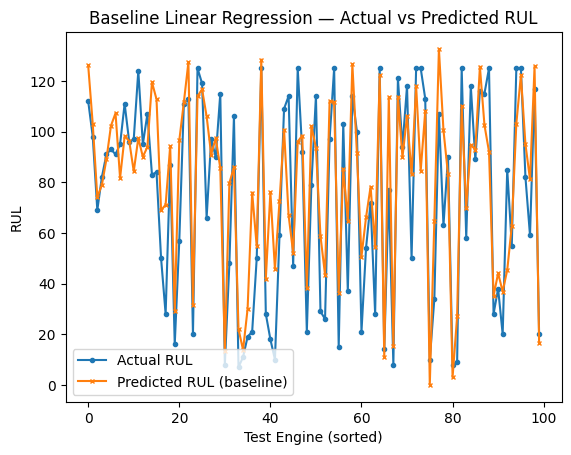

In [37]:
plt.figure()
plt.plot(y_test.values, label="Actual RUL", marker="o", ms=3)
plt.plot(baseline_pred, label="Predicted RUL (baseline)", marker="x", ms=3)
plt.xlabel("Test Engine (sorted)"); plt.ylabel("RUL")
plt.title("Baseline Linear Regression — Actual vs Predicted RUL")
plt.legend(); plt.show()

## 5. Advanced ML Models — Comparison & Best-Model Selection

We train several stronger models and compare them on RMSE / MAE / R² / NASA-Score:

- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor
- LightGBM Regressor

The best model (lowest NASA-Score, tie-broken by RMSE) is persisted to disk with `joblib` for use in the forecasting section, the GenAI assistant, and the Streamlit dashboard.

In [39]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, 
                                                   random_state=42),
    "XGBoost": XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
                            )
}


# try:
#     from lightgbm import LGBMRegressor
#     models["LightGBM"] = LGBMRegressor(
#         n_estimators=400, max_depth=-1, num_leaves=31, learning_rate=0.05,
#         subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
#     )
# except ImportError:
#     print("lightgbm not installed — skipping. Run `pip install lightgbm` to include it.")

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, None)
    results.append(evaluate(y_test, pred, name))
    fitted_models[name] = model

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[Random Forest] RMSE=17.86  MAE=12.68  R2=0.801  NASA-Score=978


c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[Gradient Boosting] RMSE=17.83  MAE=12.65  R2=0.802  NASA-Score=992
[XGBoost] RMSE=17.48  MAE=12.55  R2=0.810  NASA-Score=821


c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [40]:
results_df = pd.DataFrame(results).sort_values("NASA_Score").reset_index(drop=True)
results_df

,model,RMSE,MAE,R2,NASA_Score
0,XGBoost,17.478499,12.554165,0.809761,821.139483
1,Random Forest,17.855390,12.681835,0.801469,978.110616
2,Gradient Boosting,17.834232,12.652001,0.801939,992.024500
3,Linear Regression (baseline),20.994866,16.640718,0.725516,1332.909117


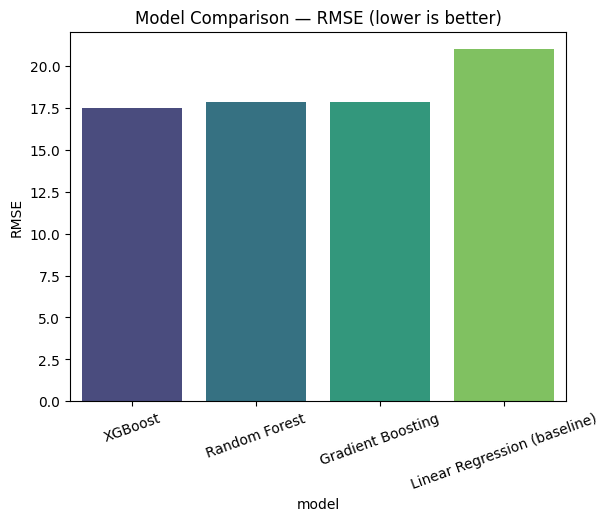

In [41]:
plt.figure()
sns.barplot(data=results_df, x="model", y="RMSE", palette="viridis")
plt.title("Model Comparison — RMSE (lower is better)")
plt.xticks(rotation=20)
plt.show()

## XGBoost model prediction

In [42]:
baseline_pred = np.clip(fitted_models['XGBoost'].predict(X_test), 0, None)

results = [evaluate(y_test, baseline_pred, "XGBoost")]

[XGBoost] RMSE=17.48  MAE=12.55  R2=0.810  NASA-Score=821


c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


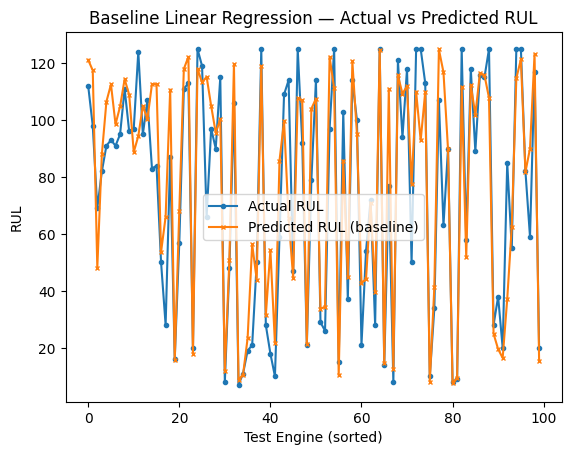

In [43]:
plt.figure()
plt.plot(y_test.values, label="Actual RUL", marker="o", ms=3)
plt.plot(baseline_pred, label="Predicted RUL (baseline)", marker="x", ms=3)
plt.xlabel("Test Engine (sorted)"); plt.ylabel("RUL")
plt.title("Baseline Linear Regression — Actual vs Predicted RUL")
plt.legend(); plt.show()

In [44]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models.get(best_model_name, baseline)
print(f"Best model selected: {best_model_name}")

import joblib
joblib.dump(best_model, os.path.join(MODEL_DIR, "best_rul_model.pkl"))
joblib.dump(scaler,     os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(FEATURE_COLS, os.path.join(MODEL_DIR, "feature_cols.pkl"))
joblib.dump(FEATURE_SENSORS, os.path.join(MODEL_DIR, "feature_sensors.pkl"))
print("Saved: best_rul_model.pkl, scaler.pkl, feature_cols.pkl, feature_sensors.pkl ->", MODEL_DIR)

Best model selected: XGBoost
Saved: best_rul_model.pkl, scaler.pkl, feature_cols.pkl, feature_sensors.pkl -> e:\ISCOP institute\Seminar\Seminar (12-7-2026)\NASA turbofan predictive maintenance\models


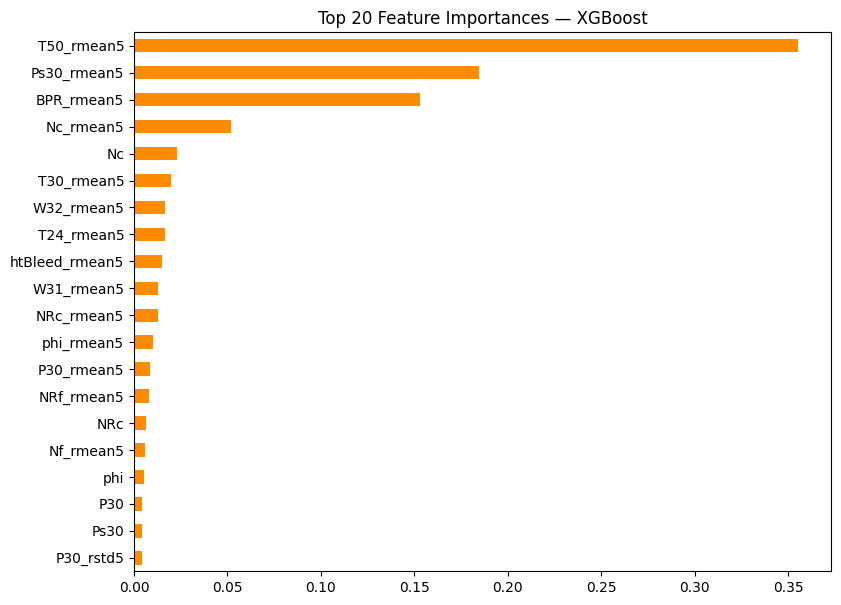

In [45]:
# Feature importance for the best model
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 7))
importances.plot(kind="barh", color="darkorange")
plt.gca().invert_yaxis()
plt.title(f"Top 20 Feature Importances — {best_model_name}")
plt.show()

## 6. GenAI Maintenance Assistant (LangChain + Google Gemini)

We wrap the RUL model's output (current RUL, degradation trend, key sensor deviations) into a natural-language **maintenance assistant** using LangChain's Gemini integration. Given an engine's health snapshot, the assistant explains the risk level and recommends next actions in plain English — useful for maintenance crews who aren't data scientists.


In [59]:
from dotenv import load_dotenv

In [60]:
load_dotenv('../.env')

True

In [61]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [47]:
test_last

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,T2,T24,T30,T50,P2,...,Ps30_rstd5,phi_rstd5,NRf_rstd5,NRc_rstd5,BPR_rstd5,htBleed_rstd5,W31_rstd5,W32_rstd5,RUL,RUL_clipped
0,1,31,0.465517,0.833333,0.0,518.67,0.412651,0.221932,0.281229,14.62,...,0.090605,0.055776,0.042367,0.017045,0.081470,0.058926,0.096137,0.034572,112,112
1,2,49,0.603448,0.416667,0.0,518.67,0.403614,0.339002,0.482444,14.62,...,0.058564,0.096003,0.012304,0.007070,0.043976,0.091287,0.054097,0.038415,98,98
2,3,126,0.408046,0.833333,0.0,518.67,0.503012,0.407892,0.618501,14.62,...,0.066629,0.089176,0.043625,0.015374,0.118985,0.069722,0.111342,0.026190,69,69
3,4,106,0.568966,0.833333,0.0,518.67,0.472892,0.512099,0.415766,14.62,...,0.027728,0.077461,0.039733,0.003215,0.081758,0.111803,0.097963,0.029144,82,82
4,5,98,0.425287,0.166667,0.0,518.67,0.319277,0.412034,0.626435,14.62,...,0.094735,0.055486,0.033855,0.009927,0.037043,0.045644,0.071259,0.139602,91,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,97,0.465517,0.750000,0.0,518.67,0.328313,0.432527,0.264855,14.62,...,0.073023,0.049212,0.056383,0.019554,0.072720,0.083333,0.048100,0.100457,137,125
96,97,134,0.574713,0.416667,0.0,518.67,0.415663,0.259865,0.483964,14.62,...,0.055616,0.046235,0.019174,0.022802,0.072341,0.111803,0.125906,0.075336,82,82
97,98,121,0.597701,0.583333,0.0,518.67,0.442771,0.620667,0.560770,14.62,...,0.069493,0.069475,0.022303,0.016600,0.083402,0.058926,0.028271,0.081977,59,59
98,99,97,0.770115,0.500000,0.0,518.67,0.237952,0.304992,0.265530,14.62,...,0.042425,0.075436,0.030495,0.024854,0.062022,0.058926,0.060693,0.108407,117,117


In [48]:
def build_engine_health_snapshot(unit_number, df_last, df_full, sensors):
    """Assemble a compact JSON-able summary of one engine's current health for the LLM prompt.
    Uses only the current predicted RUL and recent sensor deviation from a healthy baseline —
    no forecasting step is required."""
    row = df_last[df_last.unit_number == unit_number].iloc[0]
    current_rul = float(row["RUL_pred"]) if "RUL_pred" in row else float(row["RUL"])

    # Recent trend: compare the last 5 cycles vs the first 5 cycles for this engine (degradation signal)
    eng_hist = df_full[df_full.unit_number == unit_number].sort_values("time_in_cycles")
    recent_mean = eng_hist[sensors].tail(5).mean()
    early_mean = eng_hist[sensors].head(5).mean()
    deviation = (recent_mean - early_mean).abs().sort_values(ascending=False)
    top_sensors = deviation.head(5).index.tolist()

    return {
        "unit_number": int(unit_number),
        "current_cycle": int(row["time_in_cycles"]),
        "current_rul_cycles": round(current_rul, 1),
        "top_deviating_sensors": [
            {"sensor": s, "description": SENSOR_DESCRIPTIONS.get(s, s), "deviation": round(float(deviation[s]), 4)}
            for s in top_sensors
        ],
    }

# Attach model predictions to the test set so the snapshot builder can read "RUL_pred"
test_last["RUL_pred"] = np.clip(best_model.predict(X_test), 0, None)

snapshot = build_engine_health_snapshot(24, test_last, test_fe, FEATURE_SENSORS)
snapshot

{'unit_number': 24,
 'current_cycle': 186,
 'current_rul_cycles': 18.0,
 'top_deviating_sensors': [{'sensor': 'Nc',
   'description': 'Nc',
   'deviation': 0.352},
  {'sensor': 'Ps30', 'description': 'Ps30', 'deviation': 0.3464},
  {'sensor': 'NRc', 'description': 'NRc', 'deviation': 0.3368},
  {'sensor': 'T24', 'description': 'T24', 'deviation': 0.3301},
  {'sensor': 'W31', 'description': 'W31', 'deviation': 0.307}]}

In [3]:
!pip install langchain

  Using cached langchain-1.3.11-py3-none-any.whl.metadata (6.0 kB)
  Using cached langchain_core-1.4.8-py3-none-any.whl.metadata (4.7 kB)
  Using cached langgraph-1.2.8-py3-none-any.whl.metadata (4.9 kB)
  Using cached langsmith-0.9.8-py3-none-any.whl.metadata (22 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
Using cached langchain-1.3.11-py3-none-any.whl (133 kB)
Using cached langchain_core-1.4.8-py3-none-any.whl (557 kB)
Using cached langgraph-1.2.8-py3-none-any.whl (246 kB)
Using cached langgraph_sdk-0.4.2-py3-none-any.whl (160 kB)
Using cached langsmith-0.9.8-py3-none-any.whl (671 kB)
  Attempting uninstall: websockets
    Found existing installation: websockets 16.0
    Uninstalling websockets-16.0:
      Successfully uninstalled websockets-16.0
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.3.15
    Uninstalling langgraph-sdk-0.3.15:
      Successfully uninstalled langgraph-sdk-0.3.15
  Attempting uninstall: lang


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import langchain

In [51]:
print(langchain.__version__)

1.3.11


In [52]:

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


In [8]:
!pip install langchain-google-genai

  Using cached langchain_google_genai-4.2.7-py3-none-any.whl.metadata (2.7 kB)
Using cached langchain_google_genai-4.2.7-py3-none-any.whl (70 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [56]:
import json as _json

In [58]:
MAINTENANCE_PROMPT_TEMPLATE = """You are an experienced aerospace maintenance engineer assistant.
You will be given a structured health snapshot for a turbofan engine derived from sensor telemetry
and a machine learning Remaining Useful Life (RUL) model.

Engine Health Snapshot (JSON):
{snapshot}

Write a concise maintenance briefing with these sections:
1. **Health Status** — one-line verdict (Healthy / Watch / Warning / Critical) based on the current RUL.
2. **Key Drivers** — plain-language explanation of which sensors are deviating from healthy baseline and what that physically implies.
3. **Trend Read** — what the sensor deviations suggest about the pace of degradation.
4. **Recommended Actions** — 2-4 concrete, prioritized maintenance actions with suggested timing.

Keep it under 50 words, professional tone, no markdown tables.
"""

def rule_based_fallback_briefing(snapshot):
    rul = snapshot["current_rul_cycles"]
    status = "Critical" if rul < 20 else "Warning" if rul < 50 else "Watch" if rul < 100 else "Healthy"
    top = ", ".join(s["description"] for s in snapshot["top_deviating_sensors"][:3])
    return (f"Health Status: {status}. Current RUL ~{rul} cycles. "
            f"Top deviating readings vs healthy baseline: {top}. "
            f"Recommended: schedule a borescope inspection within {max(int(rul*0.3), 1)} cycles "
            f"and monitor these sensors closely on the next few runs.")

def get_maintenance_briefing(snapshot, api_key=GOOGLE_API_KEY, model_name="gemini-3-flash-preview"):
    if not api_key:
        return ("[GOOGLE_API_KEY not set] Set the GOOGLE_API_KEY environment variable to enable "
                "live Gemini responses. Showing a rule-based fallback briefing instead:\n\n"
                + rule_based_fallback_briefing(snapshot))
    try:
        llm = ChatGoogleGenerativeAI(model=model_name, google_api_key=api_key, temperature=0.3)
        prompt = PromptTemplate.from_template(MAINTENANCE_PROMPT_TEMPLATE)
        chain = prompt | llm | StrOutputParser()
        return chain.invoke({"snapshot": _json.dumps(snapshot, indent=2)})
    except Exception as e:
        return f"[GenAI call failed: {e}]\n\n" + rule_based_fallback_briefing(snapshot)

briefing = get_maintenance_briefing(snapshot)
print(briefing)

**Health Status** — CRITICAL.
**Key Drivers** — Core speed (Nc/NRc) and discharge pressure (Ps30) anomalies indicate significant compressor degradation and thermal instability.
**Trend Read** — Accelerated wear; RUL is only 18 cycles.
**Recommended Actions** — 1. Immediate borescope inspection. 2. Schedule engine replacement within 10 cycles.


**Extending the assistant (ideas to mention live in the webinar):**
- Add a LangChain **retriever** over the engine's historical maintenance logs / manuals (RAG) so the assistant can cite specific procedures.
- Add a **conversational memory** so maintenance crews can ask follow-up questions ("why sensor 4?", "what if we delay 10 cycles?").
- Add **function-calling / tools** so the LLM can trigger `predict_future_rul()` itself for what-if scenarios instead of it being precomputed.

## 8. Professional Streamlit Dashboard

The dashboard is shipped as a **separate app** (`app.py`) so it can run as a live web app during the webinar (`streamlit run app.py`), rather than inline in the notebook.

**Dashboard features:**
- Fleet overview (engine count, health distribution, at-risk engines)
- Per-engine drill-down: sensor trend charts, current & forecasted RUL (t+2 / t+5)
- GenAI Maintenance Assistant chat panel (Gemini via LangChain)
- Model card (algorithm, metrics, feature importance)

Run it with:
```bash
pip install streamlit plotly
export GOOGLE_API_KEY="your-key-here"      # optional, enables live GenAI briefings
streamlit run app.py
```

The app loads the artifacts you just saved (`models/best_rul_model.pkl`, `scaler.pkl`, `feature_cols.pkl`, `feature_sensors.pkl`) plus the raw C-MAPSS test files — so run Sections 0–6 at least once before launching it.

In [ ]:
# Sanity check: confirm the artifacts the Streamlit app expects are present
for f in ["best_rul_model.pkl", "scaler.pkl", "feature_cols.pkl", "feature_sensors.pkl"]:
    path = os.path.join(MODEL_DIR, f)
    print(f"{f:25s} -> {'OK' if os.path.exists(path) else 'MISSING'}")

print("\nNotebook complete. Launch the dashboard with:  streamlit run app.py")